In [ ]:
# Projet Phishing URL Detector - Pipeline ML

**Objectif** : Détecter les URLs malveillantes/phishing avec Machine Learning

**Membres** : Steven, Tantely Larissa, Santatra
**Dataset** : Web Page Phishing Detection Dataset sur Kaggle

**Pipeline** : EDA → Prétraitement → Modèle → Évaluation → Export

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("Tous les imports sont OK")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Tous les imports sont OK
Pandas version: 3.0.5
Scikit-learn version: 1.9.0


In [3]:
df = pd.read_csv('../data/raw/dataset_phishing.csv')
print(f"📊 Dataset chargé: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\n🔍 Aperçu:")
df.head()

📊 Dataset chargé: 11430 lignes, 89 colonnes

🔍 Aperçu:


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


🏷️ Distribution de la variable cible:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64

Phishing: 5715 (50.0%)
Légitime: 5715 (50.0%)


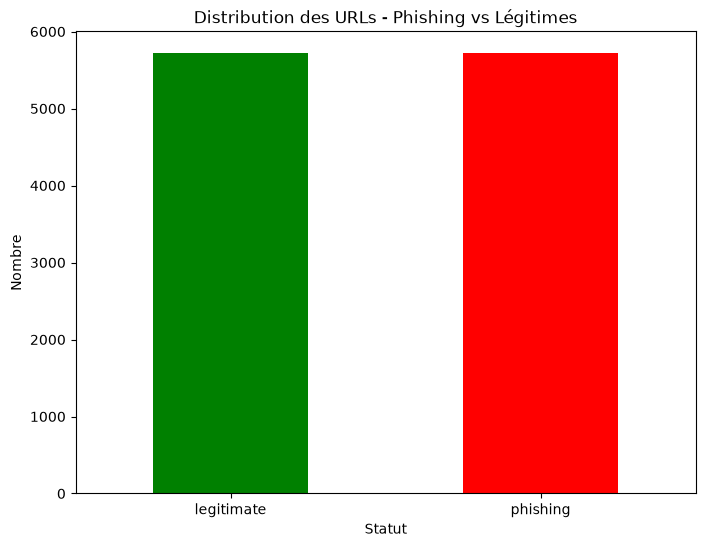

In [4]:
print("🏷️ Distribution de la variable cible:")
print(df['status'].value_counts())
print(f"\nPhishing: {df[df['status']=='phishing'].shape[0]} ({df[df['status']=='phishing'].shape[0]/len(df)*100:.1f}%)")
print(f"Légitime: {df[df['status']=='legitimate'].shape[0]} ({df[df['status']=='legitimate'].shape[0]/len(df)*100:.1f}%)")

plt.figure(figsize=(8,6))
df['status'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution des URLs - Phishing vs Légitimes')
plt.xlabel('Statut')
plt.ylabel('Nombre')
plt.xticks(rotation=0)
plt.show()

In [5]:
X = df.drop(['url', 'status'], axis=1)
y = df['status']

print(f"✅ X: {X.shape[0]} lignes, {X.shape[1]} features")
print(f"✅ y: {y.shape[0]} lignes")

✅ X: 11430 lignes, 87 features
✅ y: 11430 lignes


In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("🔢 Encodage de la cible:")
print(f"  - legitimate -> {le.transform(['legitimate'])[0]}")
print(f"  - phishing -> {le.transform(['phishing'])[0]}")

🔢 Encodage de la cible:
  - legitimate -> 0
  - phishing -> 1


In [7]:
# Vérifier les valeurs manquantes
nan_cols = X.columns[X.isnull().any()].tolist()
if nan_cols:
    print(f"⚠️ Colonnes avec NaN: {nan_cols}")
    # Supprimer les colonnes avec NaN
    X = X.drop(nan_cols, axis=1)
    print(f"✅ Colonnes supprimées: {len(nan_cols)}")
else:
    print("✅ Aucune valeur manquante détectée!")

✅ Aucune valeur manquante détectée!


In [8]:
# Split en train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"📊 Split des données:")
print(f"  - Train: {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  - Test: {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  - Features: {X_train.shape[1]}")

📊 Split des données:
  - Train: 9144 lignes (80%)
  - Test: 2286 lignes (20%)
  - Features: 87


In [9]:
# Standardiser les données (optionnel mais recommandé)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Données standardisées")
print(f"Train mean: {X_train_scaled.mean():.2f}, std: {X_train_scaled.std():.2f}")
print(f"Test mean: {X_test_scaled.mean():.2f}, std: {X_test_scaled.std():.2f}")

✅ Données standardisées
Train mean: 0.00, std: 0.96
Test mean: 0.01, std: 0.94


In [10]:
# Modèle 1: Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=5)
dt.fit(X_train_scaled, y_train)

# Prédictions
y_pred_dt = dt.predict(X_test_scaled)

# Métriques
print("="*60)
print("📊 PERFORMANCES - DECISION TREE")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_dt):.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['legitimate', 'phishing']))

📊 PERFORMANCES - DECISION TREE
Accuracy:  0.9392
Precision: 0.9419
Recall:    0.9361
F1-Score:  0.9390
AUC-ROC:   0.9392

📋 Classification Report:
              precision    recall  f1-score   support

  legitimate       0.94      0.94      0.94      1143
    phishing       0.94      0.94      0.94      1143

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



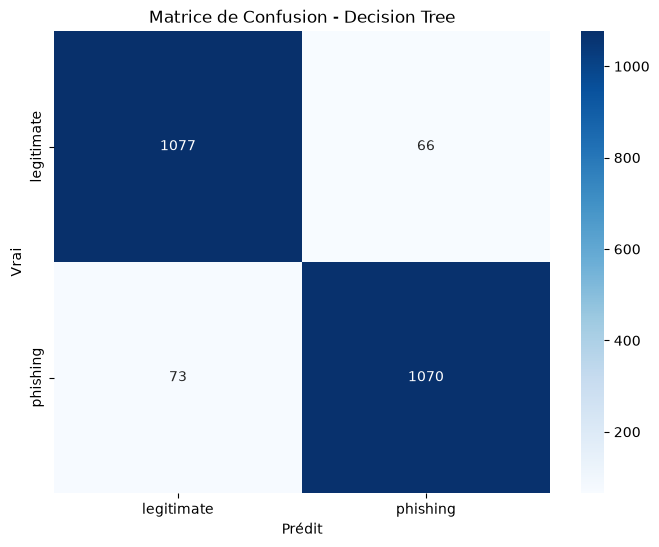

In [11]:
# Matrice de confusion
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['legitimate', 'phishing'],
            yticklabels=['legitimate', 'phishing'])
plt.title('Matrice de Confusion - Decision Tree')
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.show()

In [12]:
# Modèle 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Prédictions
y_pred_rf = rf.predict(X_test_scaled)

print("="*60)
print("📊 PERFORMANCES - RANDOM FOREST")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_rf):.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['legitimate', 'phishing']))

📊 PERFORMANCES - RANDOM FOREST
Accuracy:  0.9506
Precision: 0.9486
Recall:    0.9528
F1-Score:  0.9507
AUC-ROC:   0.9506

📋 Classification Report:
              precision    recall  f1-score   support

  legitimate       0.95      0.95      0.95      1143
    phishing       0.95      0.95      0.95      1143

    accuracy                           0.95      2286
   macro avg       0.95      0.95      0.95      2286
weighted avg       0.95      0.95      0.95      2286



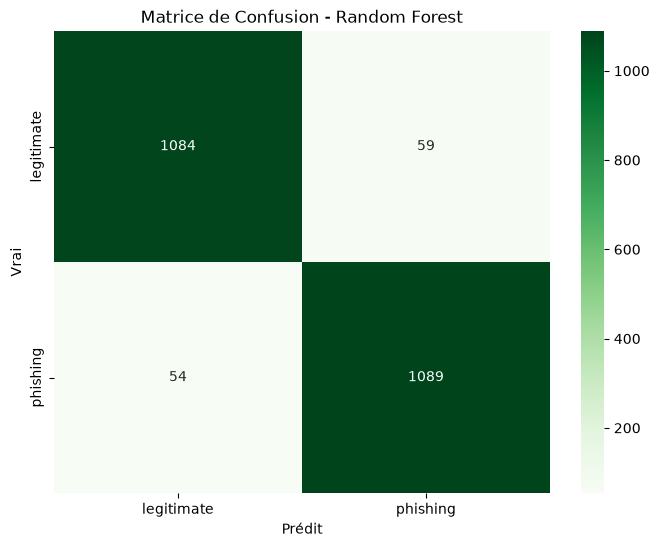

In [13]:
# Matrice de confusion Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['legitimate', 'phishing'],
            yticklabels=['legitimate', 'phishing'])
plt.title('Matrice de Confusion - Random Forest')
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.show()

📊 COMPARAISON DES MODÈLES:
          Modèle  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.939195   0.941901  0.936133  0.939008
1  Random Forest  0.950569   0.948606  0.952756  0.950677


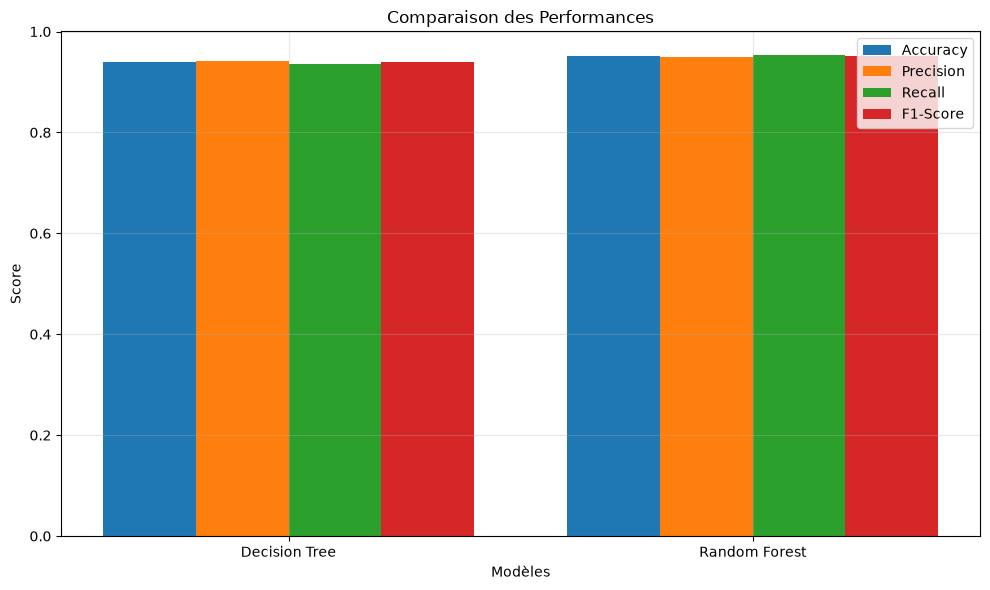

In [14]:
# Comparaison des modèles
models = ['Decision Tree', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)]
precisions = [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf)]
recalls = [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf)]
f1s = [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf)]

comparison_df = pd.DataFrame({
    'Modèle': models,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1s
})
print("📊 COMPARAISON DES MODÈLES:")
print(comparison_df)

# Visualisation
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(models))
width = 0.2
ax.bar(x - 1.5*width, accuracies, width, label='Accuracy')
ax.bar(x - 0.5*width, precisions, width, label='Precision')
ax.bar(x + 0.5*width, recalls, width, label='Recall')
ax.bar(x + 1.5*width, f1s, width, label='F1-Score')

ax.set_xlabel('Modèles')
ax.set_ylabel('Score')
ax.set_title('Comparaison des Performances')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Sauvegarder le meilleur modèle
best_model = rf if f1_score(y_test, y_pred_rf) > f1_score(y_test, y_pred_dt) else dt
best_name = "Random Forest" if best_model is rf else "Decision Tree"

# Créer les dossiers si besoin
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Sauvegarder le modèle
joblib.dump(best_model, '../models/best_model.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump(le, '../models/label_encoder.joblib')

print(f"✅ Meilleur modèle sauvegardé: {best_name}")
print(f"✅ Modèle dans: models/best_model.joblib")
print(f"✅ Scaler dans: models/scaler.joblib")
print(f"✅ Label Encoder dans: models/label_encoder.joblib")

✅ Meilleur modèle sauvegardé: Random Forest
✅ Modèle dans: models/best_model.joblib
✅ Scaler dans: models/scaler.joblib
✅ Label Encoder dans: models/label_encoder.joblib


🔝 TOP 20 FEATURES LES PLUS IMPORTANTES:
                 feature  importance
85          google_index    0.208307
86             page_rank    0.104913
56         nb_hyperlinks    0.083769
83           web_traffic    0.076063
20                nb_www    0.047521
82            domain_age    0.033016
50           phish_hints    0.031514
46     longest_word_path    0.031393
58   ratio_extHyperlinks    0.029995
62  ratio_extRedirection    0.026756
74           safe_anchor    0.025599
57   ratio_intHyperlinks    0.022700
25      ratio_digits_url    0.017282
26     ratio_digits_host    0.016042
44     longest_words_raw    0.015604
1        length_hostname    0.014968
78       domain_in_title    0.013467
0             length_url    0.013176
39      length_words_raw    0.012353
40           char_repeat    0.011807


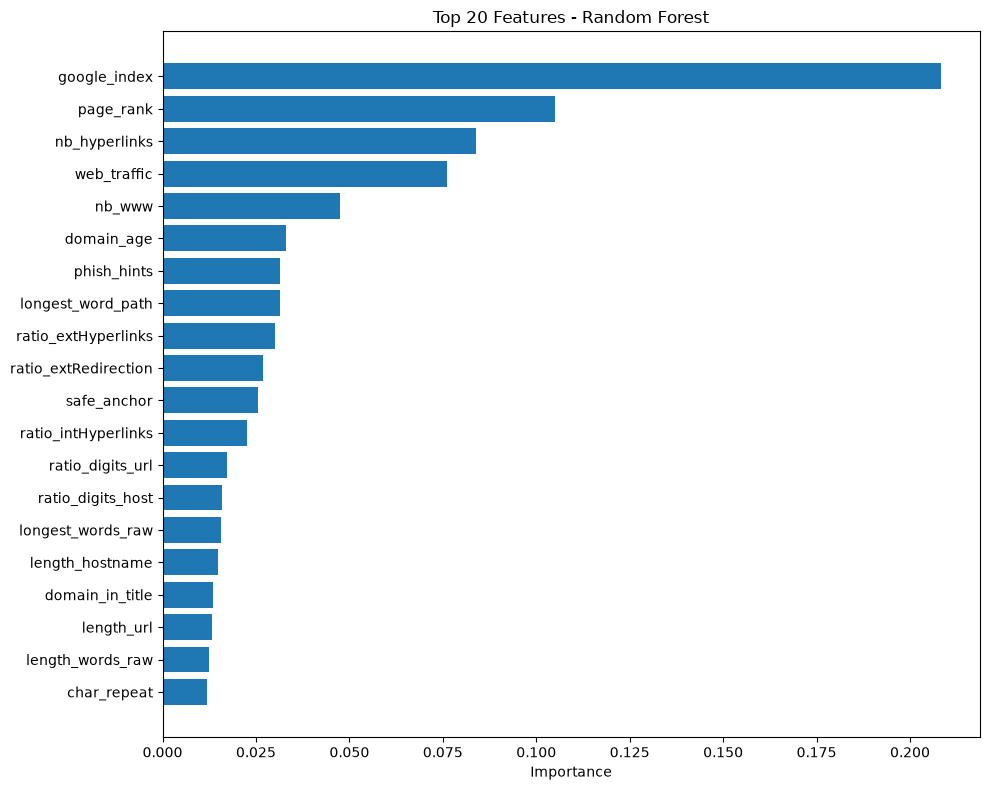

In [16]:
# Importance des features (Random Forest)
if best_model is rf:
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("🔝 TOP 20 FEATURES LES PLUS IMPORTANTES:")
    print(feature_importance.head(20))

    # Visualisation
    plt.figure(figsize=(10,8))
    top_features = feature_importance.head(20)
    plt.barh(top_features['feature'], top_features['importance'])
    plt.xlabel('Importance')
    plt.title('Top 20 Features - Random Forest')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [17]:
# Tester avec quelques URLs
test_urls = [
    "http://www.google.com",
    "http://paypal.com.secure-login.xyz",
    "https://www.facebook.com",
    "http://banking.secure-update.xyz"
]

# TODO: Fonction de prédiction (à implémenter dans src/)
print("🔜 Fonction de prédiction à implémenter dans src/")

🔜 Fonction de prédiction à implémenter dans src/


In [18]:
# Expérience : Random Forest restreint aux features 🟢🟡🟠 (sans les 🔴 infaisables en prod)

features_a_exclure = [
    'statistical_report',
    'whois_registered_domain',
    'domain_registration_length',
    'domain_age',
    'web_traffic',
    'dns_record',
    'google_index',
    'page_rank',
]

print(f"Features avant restriction : {X_train.shape[1]}")

X_train_restricted = X_train.drop(columns=features_a_exclure)
X_test_restricted = X_test.drop(columns=features_a_exclure)

print(f"Features après restriction : {X_train_restricted.shape[1]}")

# Nouveau scaler, fit uniquement sur les features restantes
scaler_restricted = StandardScaler()
X_train_restricted_scaled = scaler_restricted.fit_transform(X_train_restricted)
X_test_restricted_scaled = scaler_restricted.transform(X_test_restricted)

# Mêmes hyperparamètres que le RF original -> comparaison équitable
rf_restricted = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    n_jobs=-1
)
rf_restricted.fit(X_train_restricted_scaled, y_train)
y_pred_rf_restricted = rf_restricted.predict(X_test_restricted_scaled)

print("="*60)
print("📊 PERFORMANCES - RANDOM FOREST RESTREINT (sans 🔴)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_restricted):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_restricted):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_restricted):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf_restricted):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_rf_restricted):.4f}")

Features avant restriction : 87
Features après restriction : 79
📊 PERFORMANCES - RANDOM FOREST RESTREINT (sans 🔴)
Accuracy:  0.9261
Precision: 0.9364
Recall:    0.9143
F1-Score:  0.9252
AUC-ROC:   0.9261


In [19]:
comparison_restriction_df = pd.DataFrame({
    'Modèle': [f'Random Forest complet (87 features)', f'Random Forest restreint ({X_train_restricted.shape[1]} features)'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_rf_restricted)],
    'Precision': [precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf_restricted)],
    'Recall': [recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf_restricted)],
    'F1-Score': [f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf_restricted)],
})
print(comparison_restriction_df)

delta = (accuracy_score(y_test, y_pred_rf) - accuracy_score(y_test, y_pred_rf_restricted)) * 100
print(f"\nPerte d'accuracy en excluant les 🔴 : {delta:.2f} points")

                                  Modèle  Accuracy  Precision    Recall  \
0    Random Forest complet (87 features)  0.950569   0.948606  0.952756   
1  Random Forest restreint (79 features)  0.926072   0.936380  0.914261   

   F1-Score  
0  0.950677  
1  0.925188  

Perte d'accuracy en excluant les 🔴 : 2.45 points


In [20]:
feature_importance_restricted = pd.DataFrame({
    'feature': X_train_restricted.columns,
    'importance': rf_restricted.feature_importances_
}).sort_values('importance', ascending=False)

print("🔝 TOP 20 FEATURES - MODÈLE RESTREINT:")
print(feature_importance_restricted.head(20))

🔝 TOP 20 FEATURES - MODÈLE RESTREINT:
                 feature  importance
55         nb_hyperlinks    0.138132
20                nb_www    0.080880
57   ratio_extHyperlinks    0.057541
73           safe_anchor    0.055664
50           phish_hints    0.053492
56   ratio_intHyperlinks    0.052644
46     longest_word_path    0.040837
25      ratio_digits_url    0.038563
40           char_repeat    0.028801
61  ratio_extRedirection    0.028420
3                nb_dots    0.027203
66         links_in_tags    0.025557
44     longest_words_raw    0.025041
77       domain_in_title    0.024040
26     ratio_digits_host    0.022743
1        length_hostname    0.020038
0             length_url    0.019603
42    shortest_word_host    0.019531
13              nb_slash    0.018985
39      length_words_raw    0.018309


In [21]:
# Remplacer le modèle officiel par la version restreinte (79 features, faisable en prod)
joblib.dump(rf_restricted, '../models/best_model.joblib')
joblib.dump(scaler_restricted, '../models/scaler.joblib')
joblib.dump(le, '../models/label_encoder.joblib')  # inchangé : legitimate=0, phishing=1

print(f"✅ Nouveau modèle officiel sauvegardé : Random Forest ({X_train_restricted.shape[1]} features)")
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred_rf_restricted):.4f}")

# Geler la liste exacte des 79 features comme contrat officiel
feature_list = list(X_train_restricted.columns)
import json
with open('../models/feature_list.json', 'w') as f:
    json.dump(feature_list, f, indent=2)
print(f"✅ Liste des {len(feature_list)} features gelée dans models/feature_list.json")

✅ Nouveau modèle officiel sauvegardé : Random Forest (79 features)
✅ Accuracy: 0.9261
✅ Liste des 79 features gelée dans models/feature_list.json


In [22]:
for col in ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']:
    print(col, '->', df[col].unique())

nb_or -> [0]
ratio_nullHyperlinks -> [0]
ratio_intRedirection -> [0]
ratio_intErrors -> [0]
submit_email -> [0]
sfh -> [0]


In [23]:
import joblib
import json

print("="*70)
print("AUDIT FINAL DU MODÈLE RESTREINT (79 FEATURES)")
print("="*70)

# Chargement
model = joblib.load('../models/best_model.joblib')
scaler = joblib.load('../models/scaler.joblib')
le = joblib.load('../models/label_encoder.joblib')

with open('../models/feature_list.json') as f:
    feature_list = json.load(f)

erreurs = []
avertissements = []

# 1. Nombre de features
print(f"\n--- 1. Nombre de features ---")
print(f"model.n_features_in_  = {model.n_features_in_}")
print(f"scaler.n_features_in_ = {scaler.n_features_in_}")
print(f"len(feature_list)     = {len(feature_list)}")

if model.n_features_in_ != 79:
    erreurs.append(f"Le modèle attend {model.n_features_in_} features, pas 79 !")
if scaler.n_features_in_ != 79:
    erreurs.append(f"Le scaler attend {scaler.n_features_in_} features, pas 79 !")
if len(feature_list) != 79:
    erreurs.append(f"feature_list.json contient {len(feature_list)} features, pas 79 !")

# 2. Les 8 features supprimées ne doivent PAS être présentes
features_supprimees = [
    'statistical_report', 'whois_registered_domain', 'domain_registration_length',
    'domain_age', 'web_traffic', 'dns_record', 'google_index', 'page_rank'
]
print(f"\n--- 2. Les 8 features supprimées ---")
presentes = [f for f in features_supprimees if f in feature_list]
if presentes:
    erreurs.append(f"Ces features auraient dû être supprimées mais sont présentes : {presentes}")
else:
    print("✅ Les 8 features exclues sont bien absentes.")

# 3. Les 6 constantes DOIVENT être présentes (elles ne sont pas exclues, juste figées à 0)
features_constantes = [
    'nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection',
    'ratio_intErrors', 'submit_email', 'sfh'
]
print(f"\n--- 3. Les 6 features constantes ---")
manquantes = [f for f in features_constantes if f not in feature_list]
if manquantes:
    erreurs.append(f"Ces constantes devraient être présentes mais manquent : {manquantes}")
else:
    print("✅ Les 6 constantes sont bien présentes (valeur 0 attendue à l'extraction).")

# 4. Ordre exact : feature_list.json vs ordre interne du modèle et du scaler
print(f"\n--- 4. Ordre exact des features ---")
if hasattr(model, 'feature_names_in_'):
    model_order = list(model.feature_names_in_)
    if model_order == feature_list:
        print("✅ feature_list.json == model.feature_names_in_ (ordre identique).")
    else:
        erreurs.append("L'ordre de feature_list.json NE correspond PAS à model.feature_names_in_ !")
        for i, (a, b) in enumerate(zip(feature_list, model_order)):
            if a != b:
                print(f"   Première différence à l'index {i} : feature_list='{a}' vs model='{b}'")
                break
else:
    avertissements.append("model.feature_names_in_ absent : le modèle n'a peut-être pas été entraîné sur un DataFrame nommé.")

if hasattr(scaler, 'feature_names_in_'):
    scaler_order = list(scaler.feature_names_in_)
    if scaler_order == feature_list:
        print("✅ feature_list.json == scaler.feature_names_in_ (ordre identique).")
    else:
        erreurs.append("L'ordre de feature_list.json NE correspond PAS à scaler.feature_names_in_ !")
else:
    avertissements.append("scaler.feature_names_in_ absent : impossible de vérifier l'ordre côté scaler.")

# 5. Cohérence croisée modèle <-> scaler
print(f"\n--- 5. Cohérence modèle <-> scaler ---")
if hasattr(model, 'feature_names_in_') and hasattr(scaler, 'feature_names_in_'):
    if list(model.feature_names_in_) == list(scaler.feature_names_in_):
        print("✅ Modèle et scaler ont exactement le même ordre de features.")
    else:
        erreurs.append("Le modèle et le scaler n'ont PAS le même ordre de features !")

# 6. Label encoder
print(f"\n--- 6. Label encoder ---")
print(f"Classes : {list(le.classes_)}")
if list(le.classes_) != ['legitimate', 'phishing']:
    avertissements.append(f"Ordre des classes inattendu : {list(le.classes_)}")
else:
    print("✅ legitimate=0, phishing=1 confirmé.")

# Bilan
print("\n" + "="*70)
print("BILAN DE L'AUDIT")
print("="*70)
if erreurs:
    print(f"❌ {len(erreurs)} ERREUR(S) BLOQUANTE(S) :")
    for e in erreurs:
        print(f"   - {e}")
else:
    print("✅ Aucune erreur bloquante détectée.")

if avertissements:
    print(f"\n⚠️ {len(avertissements)} avertissement(s) :")
    for a in avertissements:
        print(f"   - {a}")

if not erreurs and not avertissements:
    print("\n🎉 Contrat modèle/scaler/feature_list cohérent. Prêt pour l'extraction des 79 features depuis une URL brute.")

AUDIT FINAL DU MODÈLE RESTREINT (79 FEATURES)

--- 1. Nombre de features ---
model.n_features_in_  = 79
scaler.n_features_in_ = 79
len(feature_list)     = 79

--- 2. Les 8 features supprimées ---
✅ Les 8 features exclues sont bien absentes.

--- 3. Les 6 features constantes ---
✅ Les 6 constantes sont bien présentes (valeur 0 attendue à l'extraction).

--- 4. Ordre exact des features ---
✅ feature_list.json == scaler.feature_names_in_ (ordre identique).

--- 5. Cohérence modèle <-> scaler ---

--- 6. Label encoder ---
Classes : ['legitimate', 'phishing']
✅ legitimate=0, phishing=1 confirmé.

BILAN DE L'AUDIT
✅ Aucune erreur bloquante détectée.

⚠️ 1 avertissement(s) :
   - model.feature_names_in_ absent : le modèle n'a peut-être pas été entraîné sur un DataFrame nommé.
